# Imports

In [1]:
!pip install datasets
!pip install --upgrade kagglehub
!pip install focal-loss

  Obtaining dependency information for datasets from https://files.pythonhosted.org/packages/b4/83/50abe521eb75744a01efe2ebe836a4b61f4df37941a776f650f291aabdf9/datasets-3.5.0-py3-none-any.whl.metadata
  Obtaining dependency information for filelock from https://files.pythonhosted.org/packages/4d/36/2a115987e2d8c300a974597416d9de88f2444426de9571f4b59b2cca3acc/filelock-3.18.0-py3-none-any.whl.metadata
  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Obtaining dependency information for numpy>=1.17 from https://files.pythonhosted.org/packages/8b/09/4ffb4d6cfe7ca6707336187951992bd8a8b9142cf345d87ab858d2d7636a/numpy-2.2.5-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 1.6 MB/s eta 0:00:00
  Obtaining dependency information for pyarrow>=15.0.0 from https://files.pythonhosted.org/packages/a0/8e/9adee63dfa3911be2382fb4d92e4b2e7d82610f9d9f668493bebaa2af50f/py


[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/49/bf/c2a24567bb6bd80c1fe7cb2ed1a332666476f69c313256aff96094bef93e/kagglehub-0.3.12-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/68.0 kB ? eta -:--:--
   ---------------------------------------- 68.0/68.0 kB 3.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for focal-loss from https://files.pythonhosted.org/packages/3a/a1/e362a8b955a417a6b37ae31088ecc3ad0fc31b50265c0924a969487eacf6/focal_loss-0.0.7-py3-none-any.whl.metadata
  Obtaining dependency information for tensorflow>=2.2 from https://files.pythonhosted.org/packages/5c/98/d145af334fd5807d6ba1ead447bf0c57a36654ea58e726d70c0d09cae913/tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/f6/d4/349f7f4bd5ea92dab34f5bb0fe31775ef6c311427a14d5a5b31ecb442341/absl_py-2.2.2-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=24.3.25 from https://files.pythonhosted.org/packages/b8/25/155f9f080d5e4bc0082edfda032ea2bc2b8fab3f4d


[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammadabuayyash1/micro-data")

print("Path to dataset files:", path)

100%|██████████| 7.72G/7.72G [07:31<00:00, 18.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohammadabuayyash1/micro-data/versions/1


In [2]:
import os,glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as T
from torchvision.transforms.functional import to_pil_image
from sklearn.metrics import accuracy_score, confusion_matrix,recall_score,precision_score,classification_report,ConfusionMatrixDisplay
from transformers import Trainer, TrainingArguments, AutoImageProcessor, AutoModelForImageClassification, EarlyStoppingCallback
from datasets import Dataset as HFDataset
from tqdm import tqdm
from focal_loss import BinaryFocalLoss
from transformers.data.data_collator import default_data_collator
import accelerate




ModuleNotFoundError: No module named 'matplotlib'

In [25]:
np.random.seed(42)

In [26]:
data = '/root/.cache/kagglehub/datasets/mohammadabuayyash1/micro-data/versions/1/Micro'

In [27]:
img_files = glob.glob(data+"**/**/*", recursive=True)
print(f'Total number of files: {len(img_files)}')

Total number of files: 23478


In [28]:
train_folder = data+'/Train'
print(f'Files in train: {len(glob.glob(train_folder+"/**/*"))}')

Files in train: 17634


In [29]:
test_folder = data+'/Test'
print(f'Files in test: {len(glob.glob(test_folder+"/**/*"))}')

Files in test: 5838


# Data Split

In [30]:
batch_size = 64
img_height = 224
img_width = 224

In [31]:
transform = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=train_folder, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


In [32]:
class_names = dataset.classes  # Access class names from the original dataset
print("Training classes:", class_names)

test_ds = datasets.ImageFolder(root=test_folder, transform=transform)

class_names = test_ds.classes # Access from test_ds
print("Test classes:", class_names)

class_names = dataset.classes # Access from original dataset for validation as well
print("Validation classes:", class_names)

Training classes: ['Lie', 'Truth']
Test classes: ['Lie', 'Truth']
Validation classes: ['Lie', 'Truth']


In [33]:
class_dict = dict(zip(range(len(class_names)), class_names))
print(class_dict)

{0: 'Lie', 1: 'Truth'}


In [34]:
# Get a single batch from the DataLoader
example_batch_imgs, example_batch_y = next(iter(train_loader))

# Check shape
print(example_batch_imgs.shape)


torch.Size([64, 3, 224, 224])


In [35]:
# Model name
MODEL_NAME = "trpakov/vit-face-expression"

# Load processor and model
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageClassification.from_pretrained(MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True)

# Adjust the classification head to match your dataset's number of classes
model.classifier = nn.Linear(model.config.hidden_size, 2)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Use model's own processor for normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to the expected input size of the model
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Apply the transform to your datasets
train_ds = datasets.ImageFolder(root=train_folder, transform=transform)

# Use train_ds, not the original dataset for the split, to ensure the transform is applied
train_ds, val_ds = random_split(train_ds, [train_size, val_size])

# Recreate DataLoaders with the correct transform and updated datasets
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers = 4, pin_memory = True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers = 4, pin_memory = True)

class_weights = torch.tensor([3.5, 1.5]).to(device)

criterion = BinaryFocalLoss(gamma=2)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at trpakov/vit-face-expression and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
class TrainerWithConfusionMatrix(Trainer):
    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        # Call the original evaluate
        output = super().evaluate(eval_dataset=eval_dataset, ignore_keys=ignore_keys, metric_key_prefix=metric_key_prefix)

        # Get predictions
        preds_output = self.predict(self.eval_dataset)
        preds = np.argmax(preds_output.predictions, axis=1)
        labels = preds_output.label_ids

        return output


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir="./model_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=8,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    fp16=True,  # Enable mixed precision training
    gradient_accumulation_steps=2, # Adjust as needed
    dataloader_num_workers=4
)

# Custom data collator function
def custom_data_collator(features):
    pixel_values = torch.stack([f[0] for f in features])
    labels = torch.tensor([f[1] for f in features])
    return {"pixel_values": pixel_values, "labels": labels}

model.config.num_labels = 2

trainer = TrainerWithConfusionMatrix(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    data_collator=custom_data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

trainer.train()

torch.save(trainer.model.state_dict(), "best_model_weights.pt")



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.010100,0.023828,0.994613
2,0.001500,0.001428,1.000000
3,0.000900,0.000859,1.000000
4,0.000700,0.000644,1.000000
5,0.000500,0.000529,1.000000
6,0.000500,0.000463,1.000000
7,0.000400,0.000418,1.000000


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: T

In [36]:
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
model.load_state_dict(torch.load("best_model_weights (3).pt"))

def run_inference(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Running Inference"):
            images, labels = batch
            images = images.to(device)
            outputs = model(pixel_values=images).logits
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

y_pred, y_true = run_inference(model, test_loader, device)


Running Inference: 100%|██████████| 92/92 [01:24<00:00,  1.08it/s]


              precision    recall  f1-score   support

         Lie       0.90      0.69      0.78      2799
       Truth       0.77      0.93      0.84      3039

    accuracy                           0.82      5838
   macro avg       0.83      0.81      0.81      5838
weighted avg       0.83      0.82      0.81      5838



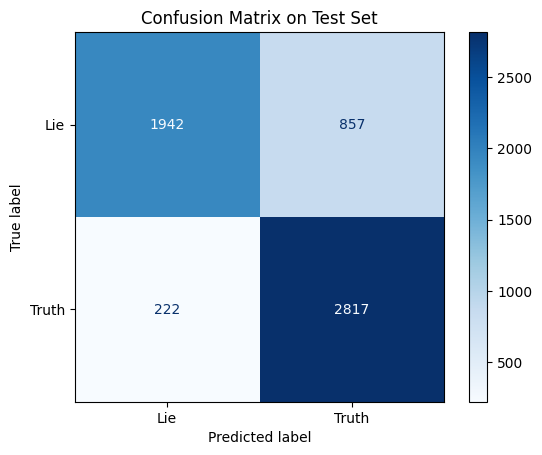

In [37]:
print(classification_report(y_true, y_pred, target_names=test_ds.classes))

# Optional: Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Test Set")
plt.show()
